In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
import numpy as np
import pandas as pd

import pandas as pd

orders = pd.read_csv("Data/olist_orders_dataset.csv")
order_items = pd.read_csv("Data/olist_order_items_dataset.csv")
products = pd.read_csv("Data/olist_products_dataset.csv")
customers = pd.read_csv("Data/olist_customers_dataset.csv")
reviews = pd.read_csv("Data/olist_order_reviews_dataset.csv")
translation = pd.read_csv("Data/product_category_name_translation.csv")

# 2. Translate Product Categories to English
products = products.merge(
    translation, on="product_category_name", how="left"
).drop(columns=["product_category_name"])
products.rename(
    columns={"product_category_name_english": "category"}, inplace=True
)
products["category"] = products["category"].fillna("other")

# 3. Handle Missing Values & Fix Data Types
orders = orders[orders["order_status"] == "delivered"].copy()

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

# 4. Deduplicate Reviews (Keep latest review per order)
reviews = reviews.sort_values("review_creation_date").drop_duplicates(
    "order_id", keep="last"
)

# 5. Merge into Unified Analytical Table
df = (
    order_items.merge(orders, on="order_id", how="inner")
    .merge(products, on="product_id", how="left")
    .merge(customers, on="customer_id", how="left")
    .merge(
        reviews[["order_id", "review_score"]], on="order_id", how="left"
    )
)

# 6. Feature Engineering
df["total_price"] = df["price"] + df["freight_value"]

In [1]:
import os

print(os.getcwd())

c:\Users\chetn\Downloads\Olist-Ecommerce-Sales-Analysis\Data


In [2]:
print(os.listdir())

['olist_sales_analysis.ipynb']


In [3]:
print(os.listdir("../"))

['app.py', 'Data', 'model.pkl', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'spam.csv', 'templates', 'vectorizer.pkl']


In [2]:
# Quick Validation Checks
print(f"Total Merged Records: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"Null Values in Key Columns:\n{df[['price', 'category', 'customer_state', 'review_score']].isnull().sum()}")
df.head(3)

Total Merged Records: 110,197
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_month', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'category', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_score', 'total_price']
Null Values in Key Columns:
price               0
category            0
customer_state      0
review_score      827
dtype: int64


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_length_cm,product_height_cm,product_width_cm,category,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,28.0,9.0,14.0,cool_stuff,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,5.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,50.0,30.0,40.0,pet_shop,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,4.0,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,33.0,13.0,33.0,furniture_decor,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,5.0,216.87


In [3]:
# Q1: Which product category has the highest revenue?
q1_top_category = df.groupby("category")["price"].sum().sort_values(ascending=False).head(5)
print("--- Q1: Top 5 Categories by Revenue ---")
print(q1_top_category)

# Q2: Which month had peak sales?
q2_monthly_sales = df.groupby(df["order_month"].astype(str))["price"].sum().sort_values(ascending=False)
print("\n--- Q2: Peak Sales Months ---")
print(q2_monthly_sales.head(5))

# Q3: Which region (customer state) performs best?
q3_top_states = df.groupby("customer_state")["price"].agg(["sum", "count"]).rename(
    columns={"sum": "total_revenue", "count": "total_items"}
).sort_values("total_revenue", ascending=False)
print("\n--- Q3: Top 5 States by Revenue ---")
print(q3_top_states.head(5))

# Q4: What is the average order value (AOV) trend?
order_totals = df.groupby(["order_id", "order_month"])["price"].sum().reset_index()
aov_trend = order_totals.groupby("order_month")["price"].mean()
print("\n--- Q4: AOV by Month ---")
print(aov_trend.tail(12))

# Q5: What is the customer review score distribution?
q5_review_dist = df["review_score"].value_counts(normalize=True).sort_index() * 100
print("\n--- Q5: Review Score Percentage Distribution ---")
print(q5_review_dist.round(2))

--- Q1: Top 5 Categories by Revenue ---
category
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
Name: price, dtype: float64

--- Q2: Peak Sales Months ---
order_month
2017-11    987765.37
2018-05    977544.69
2018-04    973534.09
2018-03    953356.25
2018-01    924645.00
Name: price, dtype: float64

--- Q3: Top 5 States by Revenue ---
                total_revenue  total_items
customer_state                            
SP                 5067633.16        46448
RJ                 1759651.13        14143
MG                 1552481.83        12916
RS                  728897.47         6134
PR                  666063.51         5649

--- Q4: AOV by Month ---
order_month
2017-09    146.361366
2017-10    144.762762
2017-11    135.514525
2017-12    131.694756
2018-01    130.802801
2018-02    126.077365
2018-03    136.135406
2018-04    143.208898
2018-05    144.

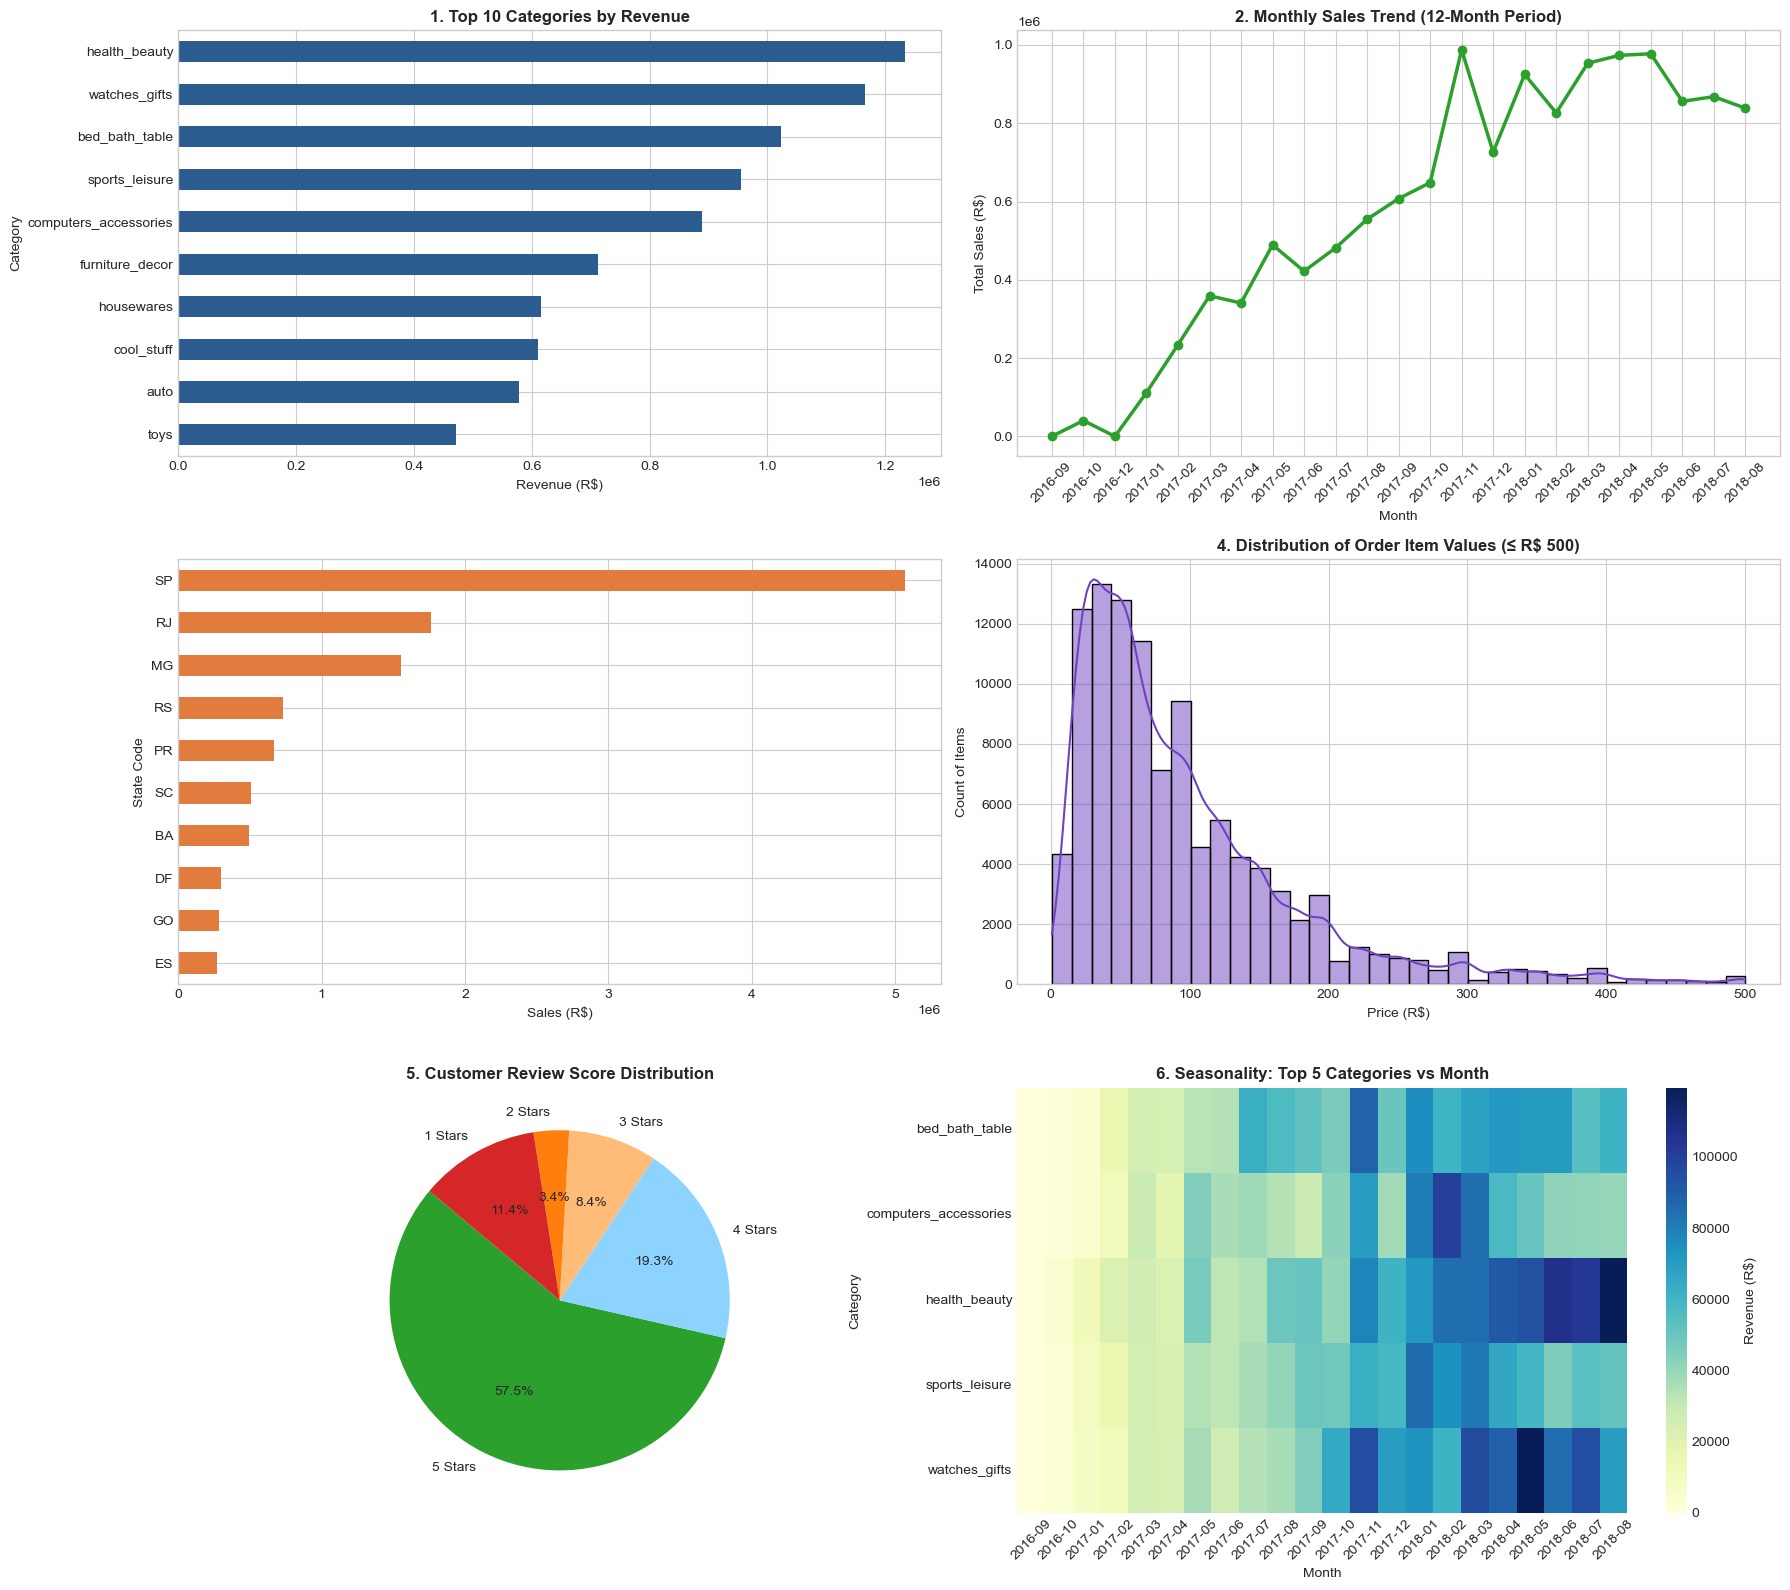

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 16))

# 1. Bar Chart: Revenue by Category
top_10_cats = df.groupby("category")["price"].sum().nlargest(10).sort_values()
top_10_cats.plot(kind="barh", ax=axes[0, 0], color="#2b5c8f")
axes[0, 0].set_title("1. Top 10 Categories by Revenue", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Revenue (R$)")
axes[0, 0].set_ylabel("Category")

# 2. Line Chart: Monthly Sales Trend
monthly_trend = df.groupby(df["order_month"].astype(str))["price"].sum()
axes[0, 1].plot(monthly_trend.index, monthly_trend.values, marker="o", color="#2ca02c", linewidth=2.5)
axes[0, 1].set_title("2. Monthly Sales Trend (12-Month Period)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Month")
axes[0, 1].set_ylabel("Total Sales (R$)")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Bar Chart: Regional Sales (Top 10 States)
top_states_rev = df.groupby("customer_state")["price"].sum().nlargest(10).sort_values()
top_states_rev.plot(kind="barh", ax=axes[1, 0], color="#e27c3e")
axes[1, 1].set_title("3. Regional Sales (Top 10 States)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Sales (R$)")
axes[1, 0].set_ylabel("State Code")

# 4. Histogram: Order Values (Item Price)
sns.histplot(df[df["price"] <= 500]["price"], bins=35, kde=True, ax=axes[1, 1], color="#6f42c1")
axes[1, 1].set_title("4. Distribution of Order Item Values (≤ R$ 500)", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Price (R$)")
axes[1, 1].set_ylabel("Count of Items")

# 5. Pie Chart: Review Scores Distribution
reviews_clean = df["review_score"].dropna().value_counts().sort_index(ascending=False)
axes[2, 0].pie(
    reviews_clean,
    labels=[f"{int(k)} Stars" for k in reviews_clean.index],
    autopct="%1.1f%%",
    colors=["#2ca02c", "#8cd3ff", "#ffbb78", "#ff7f0e", "#d62728"],
    startangle=140
)
axes[2, 0].set_title("5. Customer Review Score Distribution", fontsize=12, fontweight="bold")

# 6. Heatmap: Top 5 Categories vs Month
top_5_cats = df.groupby("category")["price"].sum().nlargest(5).index
cat_month_matrix = df[df["category"].isin(top_5_cats)].pivot_table(
    index="category",
    columns=df["order_month"].astype(str),
    values="price",
    aggfunc="sum",
    fill_value=0
)
sns.heatmap(cat_month_matrix, cmap="YlGnBu", ax=axes[2, 1], cbar_kws={"label": "Revenue (R$)"})
axes[2, 1].set_title("6. Seasonality: Top 5 Categories vs Month", fontsize=12, fontweight="bold")
axes[2, 1].set_xlabel("Month")
axes[2, 1].set_ylabel("Category")
axes[2, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()